<a href="https://colab.research.google.com/github/onatsf/whoop/blob/main/Onat_Whoop_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WHOOP  Project Exploratory Data Analysis

**Author:** Onat Safak  
**Course:** NYU Data Bootcamp (Spring 2026)

This notebook is the EDA half of the final project. The modeling notebook (`02_Modeling.ipynb`) consumes the same feature pipeline from `src/features.py`.

## Goals
1. Understand the shape, range, and quality of ~8 months of personal WHOOP data.
2. Visualize how Recovery, HRV, RHR, and Strain move through time.
3. Quantify pairwise relationships and look for predictors of Recovery.
4. Document feature-engineering decisions that feed the modeling notebook.

## Methodology note: we don't peek at the test set

Because this is a predictive-modeling project, we make the train / test split the very first thing we do after loading, and run all EDA on the training portion only. Looking at the test set during EDA would let our intuitions (and any feature engineering decisions we make based on what we see) leak future information into the model. The split is an 80 / 20 time-ordered hold-out:
- **Train**: first ~80% of days — exploration, feature engineering, model selection.
- **Test**:  last ~20% of days — touched only at the very end in 02_Modeling.ipynb.

The single helper time_aware_split in src/features.py defines the split, so the EDA notebook and the modeling notebook are guaranteed to use the same cutoff.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import statsmodels
except ImportError:
    !pip install -q statsmodels
    import statsmodels

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 80)

DATA_DIR = '/content/data'
FIG_DIR  = '/content/figures'
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
"""
Feature engineering for the WHOOP final project.

Loads the four WHOOP exports, joins them on cycle date, and builds a single
modeling DataFrame indexed by date with:

    - physiological metrics from the daily cycle
    - autoregressive lag features (1, 2, 3, 7 days) on Recovery %, HRV, Strain
    - rolling 7-day workout / strain statistics
    - sleep timing features derived from the onset/wake timestamps
    - day-of-week and weekend flag
    - binary lifestyle features pivoted from the journal entries
    - the prediction target: next-day Recovery %  ('recovery_next')
"""

from __future__ import annotations

import os
from typing import Optional

import numpy as np
import pandas as pd

def _read_csv(data_dir: str, name: str) -> pd.DataFrame:
    return pd.read_csv(os.path.join(data_dir, name))


def load_cycles(data_dir: str) -> pd.DataFrame:
    """One row per WHOOP physiological cycle (≈ one row per day)."""
    df = _read_csv(data_dir, "physiological_cycles.csv")
    df["cycle_start"] = pd.to_datetime(df["Cycle start time"])
    df["date"] = df["cycle_start"].dt.normalize()
    df = df.sort_values("date").reset_index(drop=True)
    return df


def load_workouts(data_dir: str) -> pd.DataFrame:
    df = _read_csv(data_dir, "workouts.csv")
    df["workout_start"] = pd.to_datetime(df["Workout start time"])
    df["date"] = df["workout_start"].dt.normalize()
    return df


def load_sleeps(data_dir: str) -> pd.DataFrame:
    df = _read_csv(data_dir, "sleeps.csv")
    df["sleep_onset"] = pd.to_datetime(df["Sleep onset"])
    df["wake_onset"] = pd.to_datetime(df["Wake onset"])
    df["date"] = df["sleep_onset"].dt.normalize()
    return df


def load_journal(data_dir: str) -> pd.DataFrame:
    df = _read_csv(data_dir, "journal_entries.csv")
    df["cycle_start"] = pd.to_datetime(df["Cycle start time"])
    df["date"] = df["cycle_start"].dt.normalize()
    return df


_COL_MAP = {
    "Recovery score %":            "recovery",
    "Resting heart rate (bpm)":    "rhr",
    "Heart rate variability (ms)": "hrv",
    "Skin temp (celsius)":         "skin_temp",
    "Blood oxygen %":              "spo2",
    "Day Strain":                  "strain",
    "Energy burned (cal)":         "calories",
    "Max HR (bpm)":                "max_hr",
    "Average HR (bpm)":            "avg_hr",
    "Sleep performance %":         "sleep_perf",
    "Respiratory rate (rpm)":      "resp_rate",
    "Asleep duration (min)":       "sleep_min",
    "In bed duration (min)":       "in_bed_min",
    "Light sleep duration (min)":  "light_min",
    "Deep (SWS) duration (min)":   "deep_min",
    "REM duration (min)":          "rem_min",
    "Awake duration (min)":        "awake_min",
    "Sleep need (min)":            "sleep_need_min",
    "Sleep debt (min)":            "sleep_debt_min",
    "Sleep efficiency %":          "sleep_eff",
    "Sleep consistency %":         "sleep_consistency",
}


def tidy_cycles(cycles: pd.DataFrame) -> pd.DataFrame:
    df = cycles.rename(columns=_COL_MAP).copy()
    keep = ["date"] + list(_COL_MAP.values()) + ["Sleep onset", "Wake onset"]
    df = df[keep]
    df["sleep_onset_dt"] = pd.to_datetime(df["Sleep onset"])
    df["wake_onset_dt"] = pd.to_datetime(df["Wake onset"])
    df = df.drop(columns=["Sleep onset", "Wake onset"])
    return df


#Feature builders
def sleep_timing_features(df: pd.DataFrame) -> pd.DataFrame:
    """Bedtime, wake time (decimal hours), and total in-bed duration."""
    df = df.copy()
    # Bedtime expressed as hours from noon so that "1am" -> 13, "10pm" -> 10
    bedtime = df["sleep_onset_dt"].dt.hour + df["sleep_onset_dt"].dt.minute / 60.0
    df["bedtime_hr"] = (bedtime - 12.0) % 24.0      # 0 = noon, 13 = 1am
    waketime = df["wake_onset_dt"].dt.hour + df["wake_onset_dt"].dt.minute / 60.0
    df["wake_hr"] = waketime
    return df


def workout_daily_features(workouts: pd.DataFrame) -> pd.DataFrame:
    """Aggregate workouts to one row per day."""
    g = workouts.groupby("date")
    daily = pd.DataFrame({
        "n_workouts":      g.size(),
        "total_workout_min": g["Duration (min)"].sum(),
        "total_workout_strain": g["Activity Strain"].sum(),
        "max_workout_strain":   g["Activity Strain"].max(),
        "did_running":     g["Activity name"].apply(lambda s: int("Running" in s.values)),
        "did_lifting":     g["Activity name"].apply(
            lambda s: int(any(a in s.values for a in ["Weightlifting", "Strength Trainer"]))
        ),
    }).reset_index()
    return daily


def journal_daily_features(journal: pd.DataFrame) -> pd.DataFrame:
    """Pivot the journal yes/no answers into binary columns, one row per day."""
    j = journal.copy()
    j["yes"] = j["Answered yes"].astype(int)
    pivot = (j.pivot_table(index="date", columns="Question text",
                           values="yes", aggfunc="max")
              .reset_index())
    # tidy column names
    rename = {
        "Ate food close to bedtime?":               "j_late_food",
        "Consumed caffeine?":                       "j_caffeine",
        "Have any alcoholic drinks?":               "j_alcohol",
        "Tracked your calories?":                   "j_tracked_cal",
        "Consumed protein?":                        "j_protein",
        "Consumed magnesium?":                      "j_magnesium",
        "Read (non-screened device) while in bed?": "j_read_in_bed",
        "Dimmed your lights after sunset?":         "j_dimmed_lights",
        "Saw direct sunlight upon waking up?":      "j_sunlight_am",
    }
    pivot = pivot.rename(columns=rename)
    return pivot


def add_lag_features(df: pd.DataFrame, cols: list[str], lags: list[int]) -> pd.DataFrame:
    """Add y_{t-k} columns for autoregressive modeling."""
    df = df.copy().sort_values("date")
    for c in cols:
        for k in lags:
            df[f"{c}_lag{k}"] = df[c].shift(k)
    return df


def add_rolling_features(df: pd.DataFrame, cols: list[str], window: int = 7) -> pd.DataFrame:
    """Trailing window means (shifted by 1 so we don't peek at today)."""
    df = df.copy().sort_values("date")
    for c in cols:
        df[f"{c}_roll{window}"] = (df[c].shift(1)
                                       .rolling(window=window, min_periods=3)
                                       .mean())
    return df


#Top-level assembly

def build_modeling_frame(data_dir: str) -> pd.DataFrame:
    """One stop shop: load everything, join, engineer, and return final frame."""
    cycles = tidy_cycles(load_cycles(data_dir))
    cycles = sleep_timing_features(cycles)

    workouts = load_workouts(data_dir)
    workout_daily = workout_daily_features(workouts)

    journal = load_journal(data_dir)
    journal_daily = journal_daily_features(journal)

    df = cycles.merge(workout_daily, on="date", how="left") \
               .merge(journal_daily, on="date", how="left")

    # fill missing workout/journal counts with 0 (no entry = didn't happen)
    workout_cols = ["n_workouts", "total_workout_min", "total_workout_strain",
                    "max_workout_strain", "did_running", "did_lifting"]
    df[workout_cols] = df[workout_cols].fillna(0)
    journal_cols = [c for c in df.columns if c.startswith("j_")]
    df[journal_cols] = df[journal_cols].fillna(0)

    # day-of-week / weekend
    df["dow"] = df["date"].dt.dayofweek
    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    # autoregressive lags on the key persistent signals. Recovery gets a
    # denser lag set (1..7) because PACF order selection lives there.
    df = add_lag_features(df, cols=["recovery"], lags=[1, 2, 3, 4, 5, 6, 7])
    df = add_lag_features(df, cols=["hrv", "rhr", "strain", "sleep_perf"],
                          lags=[1, 2, 3, 7])

    # rolling 7-day means for training-load context
    df = add_rolling_features(df,
                              cols=["strain", "total_workout_min",
                                    "total_workout_strain", "n_workouts"],
                              window=7)

    # target: next-day recovery
    df = df.sort_values("date").reset_index(drop=True)
    df["recovery_next"] = df["recovery"].shift(-1)

    # WHOOP's standard Red / Yellow / Green zoning
    def zone(r: float) -> Optional[str]:
        if pd.isna(r):
            return np.nan
        if r < 34:
            return "Red"
        if r < 67:
            return "Yellow"
        return "Green"

    df["recovery_next_zone"] = df["recovery_next"].apply(zone)

    return df


def time_aware_split(df: pd.DataFrame, test_frac: float = 0.20):
    """
    Single source of truth for the train / test split used by both notebooks.

    Returns (train_df, test_df, cutoff_date) where the test set is the most
    recent `test_frac` of rows, in original time order. Using a single helper
    means the EDA notebook, the modeling notebook, and the executive summary
    all reference the same split — no chance of a leak from one to the other.
    """
    df = df.sort_values("date").reset_index(drop=True)
    n_test = int(round(len(df) * test_frac))
    cutoff_idx = len(df) - n_test
    train_df = df.iloc[:cutoff_idx].copy()
    test_df  = df.iloc[cutoff_idx:].copy()
    cutoff_date = test_df["date"].iloc[0]
    return train_df, test_df, cutoff_date


## 2 · Load the four WHOOP exports

In [3]:
cycles_raw  = load_cycles('/content')
workouts    = load_workouts('/content')
sleeps      = load_sleeps('/content')
journal     = load_journal('/content')

print('cycles  :', cycles_raw.shape)
print('workouts:', workouts.shape)
print('sleeps  :', sleeps.shape)
print('journal :', journal.shape)
print('date range:', cycles_raw['date'].min().date(), '→', cycles_raw['date'].max().date())

cycles  : (237, 28)
workouts: (340, 19)
sleeps  : (258, 21)
journal : (1050, 8)
date range: 2025-09-17 → 2026-05-12


**Note on the data.** Each `physiological_cycles` row is one WHOOP cycle (roughly one day, midnight-to-midnight after WHOOP's adjustments). `workouts`, `sleeps`, and `journal` link back via the cycle start time.

## 3 · Train / test split done before EDA

We split the cycles into training and test sets **before exploring**. From this point forward, every plot, summary statistic, and feature decision in this notebook is computed on `cycles_train` only. The test set is locked away until the modeling notebook.

In [4]:
cycles = tidy_cycles(cycles_raw).drop_duplicates(subset='date', keep='last')
cycles_train, cycles_test, cutoff = time_aware_split(cycles, test_frac=0.20)

print(f'Training cycles : {len(cycles_train):>4}  ({cycles_train.date.min().date()} → {cycles_train.date.max().date()})')
print(f'Test cycles     : {len(cycles_test):>4}  ({cycles_test.date.min().date()} → {cycles_test.date.max().date()})')
print(f'Cutoff date     : {cutoff.date()}')


Training cycles :  185  (2025-09-17 → 2026-03-26)
Test cycles     :   46  (2026-03-27 → 2026-05-12)
Cutoff date     : 2026-03-27


**Train vs test sanity check.** A time-ordered split is only valid if the test period isn't from a wildly different regime than training (e.g. an injury, an extended trip, a season change). The two-sample summary below confirms the marginal distributions are similar enough to make hold-out evaluation meaningful.

In [5]:
compare_cols = ['recovery','hrv','rhr','strain','sleep_perf','sleep_min']
summary = pd.DataFrame({
    'train_mean': cycles_train[compare_cols].mean(),
    'test_mean':  cycles_test[compare_cols].mean(),
    'train_std':  cycles_train[compare_cols].std(),
    'test_std':   cycles_test[compare_cols].std(),
}).round(1)
summary['Δ_mean'] = (summary['test_mean'] - summary['train_mean']).round(1)
summary


,train_mean,test_mean,train_std,test_std,Δ_mean
recovery,53.2,53.9,23.8,24.7,0.7
hrv,87.0,82.7,20.5,23.1,-4.3
rhr,64.7,61.1,6.9,8.1,-3.6
strain,10.7,13.0,3.7,3.6,2.3
sleep_perf,66.0,66.5,19.8,19.9,0.5
sleep_min,369.2,382.9,98.4,82.3,13.7


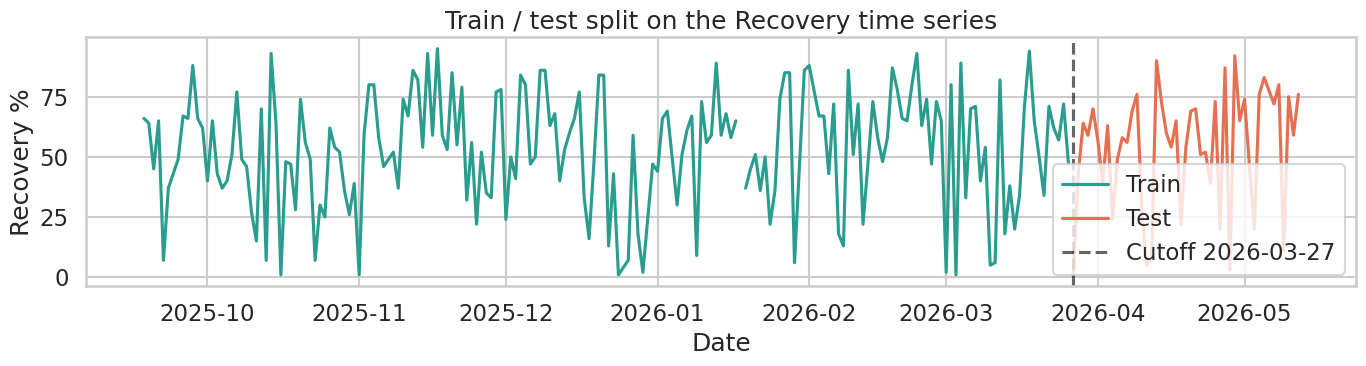

In [6]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(cycles_train['date'], cycles_train['recovery'], color='#2a9d8f', label='Train')
ax.plot(cycles_test['date'],  cycles_test['recovery'],  color='#e76f51', label='Test')
ax.axvline(cutoff, color='black', linestyle='--', alpha=0.6, label=f'Cutoff {cutoff.date()}')
ax.set_title('Train / test split on the Recovery time series')
ax.set_ylabel('Recovery %'); ax.set_xlabel('Date')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_train_test_split.png', dpi=130, bbox_inches='tight')
plt.show()


## 4 · Data quality scan (training set only)

In [7]:
display(cycles_train.head())
display(cycles_train.describe().T[['mean','std','min','max']].round(2))


,date,recovery,rhr,hrv,skin_temp,spo2,strain,calories,max_hr,avg_hr,sleep_perf,resp_rate,sleep_min,in_bed_min,light_min,deep_min,rem_min,awake_min,sleep_need_min,sleep_debt_min,sleep_eff,sleep_consistency,sleep_onset_dt,wake_onset_dt
0,2025-09-17,NaN,NaN,NaN,NaN,NaN,13.9,1465.0,178.0,93.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,2025-09-18,66.0,70.0,87.0,34.20,96.45,15.5,3460.0,179.0,83.0,77.0,17.5,358.0,405.0,213.0,54.0,91.0,47.0,542.0,0.0,88.0,NaN,2025-09-18 02:04:23,2025-09-18 08:50:24
2,2025-09-19,64.0,61.0,87.0,32.98,97.31,14.7,3256.0,167.0,86.0,73.0,16.6,367.0,409.0,123.0,106.0,138.0,42.0,608.0,92.0,89.0,NaN,2025-09-19 03:24:28,2025-09-19 10:14:29
3,2025-09-20,45.0,70.0,86.0,33.19,95.55,17.5,3712.0,174.0,86.0,31.0,17.4,294.0,421.0,180.0,17.0,97.0,127.0,631.0,120.0,69.0,57.0,2025-09-20 04:44:18,2025-09-20 11:46:58
4,2025-09-21,65.0,65.0,101.0,33.61,95.18,7.3,2170.0,158.0,71.0,63.0,17.1,344.0,388.0,198.0,63.0,83.0,44.0,658.0,127.0,88.0,74.0,2025-09-21 04:22:50,2025-09-21 10:52:51


,mean,std,min,max
date,2025-12-20 21:08:45.405405440,NaN,2025-09-17 00:00:00,2026-03-26 00:00:00
recovery,53.196721,23.845994,1.0,95.0
rhr,64.68306,6.875509,54.0,85.0
hrv,86.961749,20.470125,22.0,145.0
skin_temp,34.150765,0.654096,32.46,36.1
spo2,95.223149,1.261712,89.5,99.0
strain,10.741081,3.741126,4.2,19.8
calories,2647.32973,532.098097,1465.0,5214.0
max_hr,157.875676,13.713319,128.0,192.0
avg_hr,77.448649,5.285214,66.0,93.0


## 5 · Univariate distributions (training set)

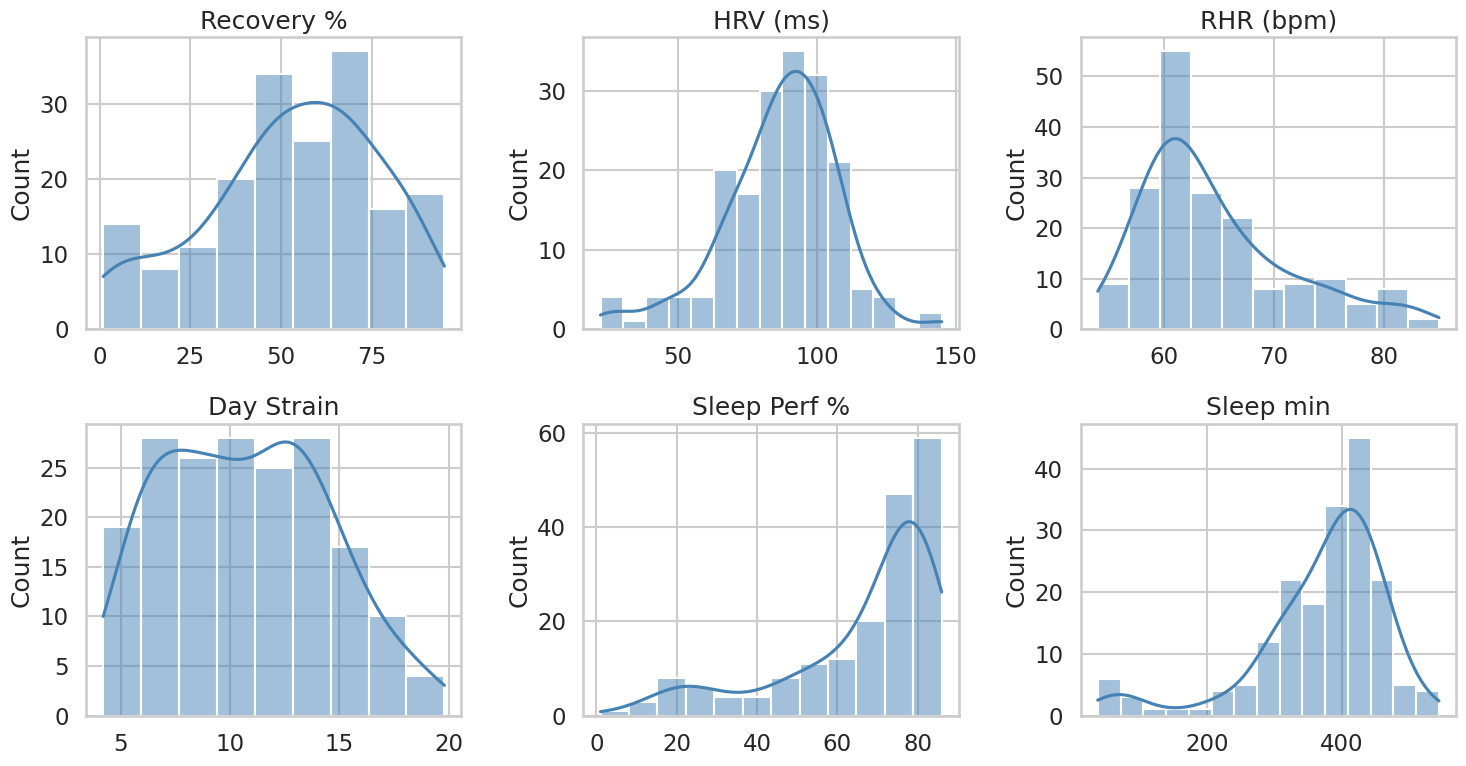

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ['recovery','hrv','rhr','strain','sleep_perf','sleep_min']
titles  = ['Recovery %','HRV (ms)','RHR (bpm)','Day Strain','Sleep Perf %','Sleep min']
for ax, col, t in zip(axes.flat, metrics, titles):
    sns.histplot(cycles_train[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(t); ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_distributions.png', dpi=130, bbox_inches='tight')
plt.show()


Recovery is roughly symmetric and centered just above 50% — typical for an active student with normal sleep variability. HRV and RHR are tight single-mode distributions; sleep performance is mildly left-skewed.

## 6 · Time-series view of the headline metrics

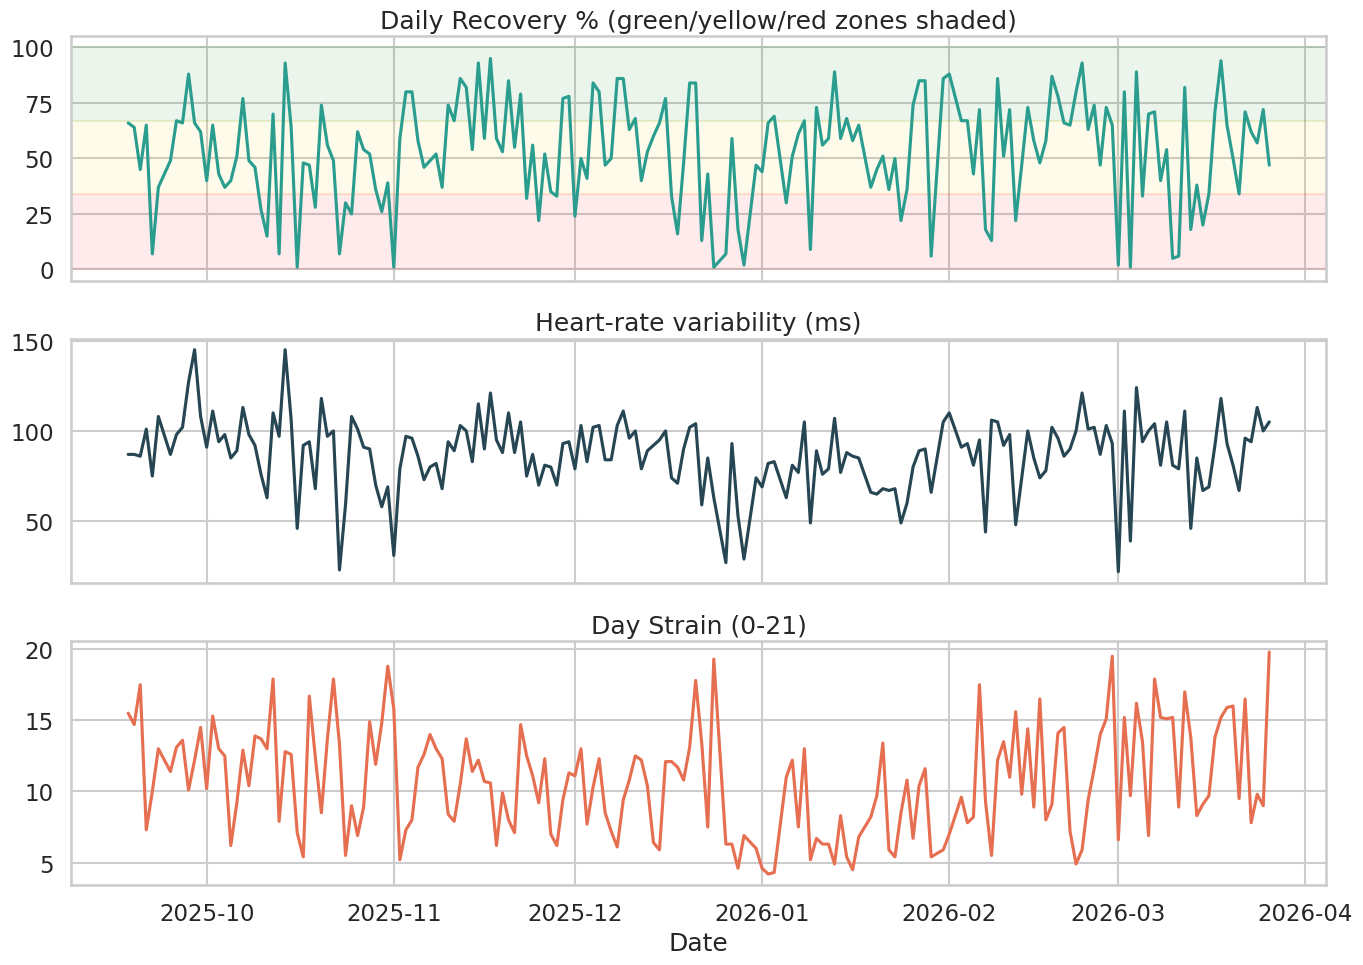

In [9]:
cycles_ts = cycles_train.sort_values('date').dropna(subset=['recovery']).copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(cycles_ts['date'], cycles_ts['recovery'], color='#2a9d8f')
axes[0].axhspan(67, 100, color='green', alpha=0.08)
axes[0].axhspan(34, 67, color='gold',  alpha=0.08)
axes[0].axhspan(0,  34, color='red',   alpha=0.08)
axes[0].set_title('Daily Recovery % (green/yellow/red zones shaded)')

axes[1].plot(cycles_ts['date'], cycles_ts['hrv'], color='#264653')
axes[1].set_title('Heart-rate variability (ms)')

axes[2].plot(cycles_ts['date'], cycles_ts['strain'], color='#e76f51')
axes[2].set_title('Day Strain (0-21)')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_timeseries.png', dpi=130, bbox_inches='tight')
plt.show()


The Recovery series shows strong day-to-day oscillation but no clean long-term trend — exactly the kind of *autoregressive* structure the modeling notebook will try to exploit.

## 7 · Autoregressive structure: ACF, PACF, stationarity

Before we model Recovery, we should ask the basic time-series questions: is the series stationary, and how much memory does it carry from one day to the next? The standard toolkit gives us **ADF** (stationarity test), **ACF** (autocorrelation at each lag), and **PACF** (autocorrelation at lag *k* with the influence of shorter lags partialled out). PACF is the classical way to choose an AR(p) order: the lag at which the PACF cuts off into the confidence band is a defensible *p*.

In [10]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure a regularly-spaced daily series for ACF/PACF
rec_train = (cycles_train.set_index('date')['recovery']
                          .asfreq('D')
                          .interpolate(limit=2))
rec_train = rec_train.dropna()
print(f'Daily Recovery series for AR diagnostics: {len(rec_train)} days')

adf_stat, p_value, *_ = adfuller(rec_train)
print(f'ADF test statistic : {adf_stat:.3f}')
print(f'ADF p-value        : {p_value:.4f}')
print('Conclusion         :',
      'stationary at 5% level' if p_value < 0.05 else 'NOT stationary at 5% level')


Daily Recovery series for AR diagnostics: 190 days
ADF test statistic : -4.441
ADF p-value        : 0.0003
Conclusion         : stationary at 5% level


A p-value below 0.05 means we reject the null of a unit root — i.e. the series doesn't drift away, it returns to a mean. That's exactly the regime an AR(p) model is built for.

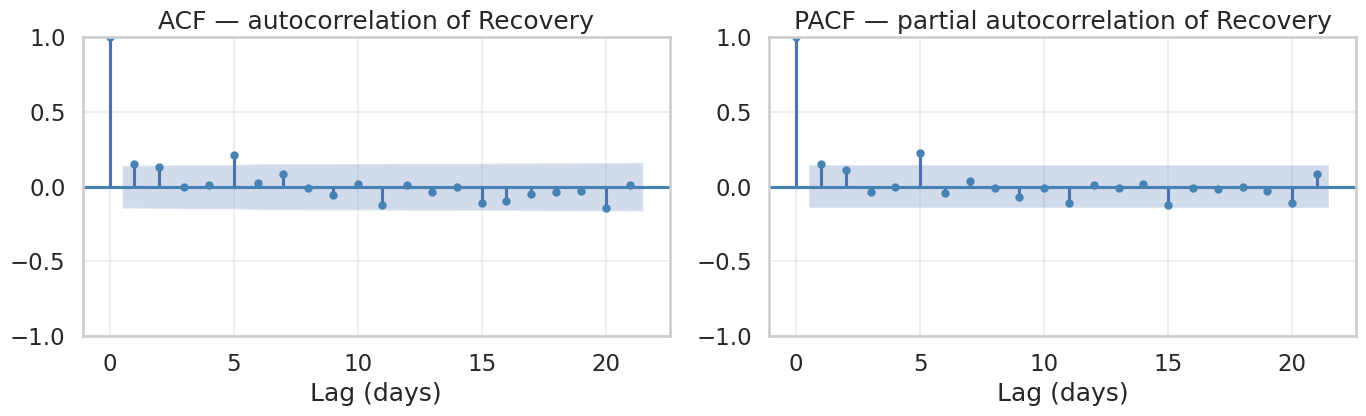

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_acf(rec_train,  lags=21, ax=axes[0], color='steelblue')
plot_pacf(rec_train, lags=21, ax=axes[1], method='ywm', color='steelblue')
axes[0].set_title('ACF — autocorrelation of Recovery')
axes[1].set_title('PACF — partial autocorrelation of Recovery')
for ax in axes:
    ax.set_xlabel('Lag (days)'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_acf_pacf.png', dpi=140, bbox_inches='tight')
plt.show()


**Reading the plots.** A spike that pokes outside the shaded confidence band is statistically significant. Typically for WHOOP-style daily Recovery we expect:
- **ACF** decays gradually across several lags (the indirect   influence of yesterday on tomorrow propagates through the chain).
- **PACF** has a strong spike at lag 1 and the spikes at lag 2+   collapse into the band — the signature of an **AR(1)** process.

We let the PACF tell us the order, then use that order when fitting the explicit autoregression in the modeling notebook.

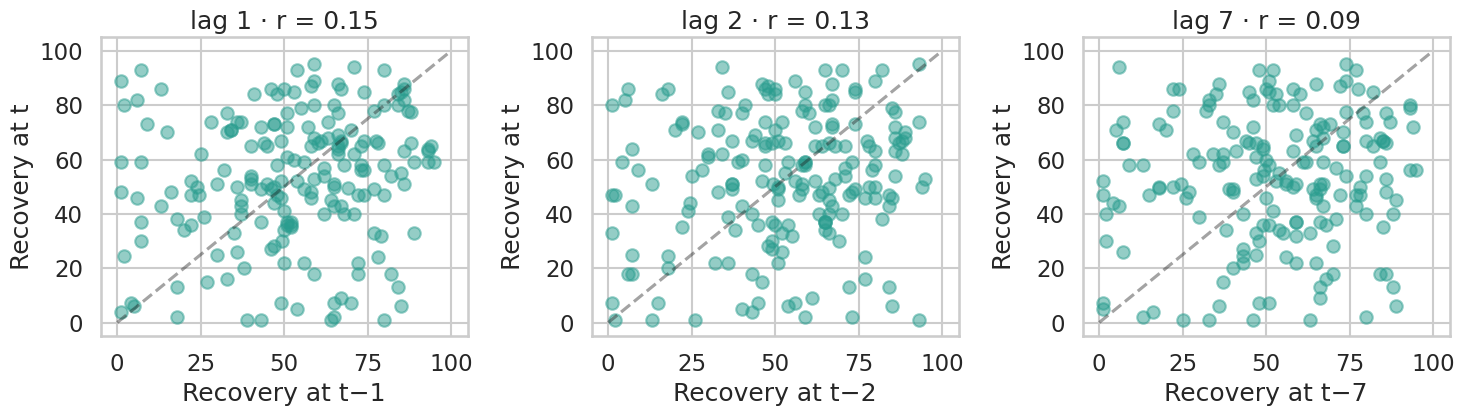

In [12]:
# Lag-scatter plots show the same structure visually
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, lag in zip(axes, [1, 2, 7]):
    ax.scatter(rec_train.shift(lag), rec_train, alpha=0.5, color='#2a9d8f')
    ax.plot([0,100],[0,100], 'k--', alpha=0.4)
    ax.set_xlabel(f'Recovery at t−{lag}'); ax.set_ylabel('Recovery at t')
    r = rec_train.corr(rec_train.shift(lag))
    ax.set_title(f'lag {lag} · r = {r:.2f}')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_lag_scatter.png', dpi=140, bbox_inches='tight')
plt.show()


## 8 · Day-of-week patterns

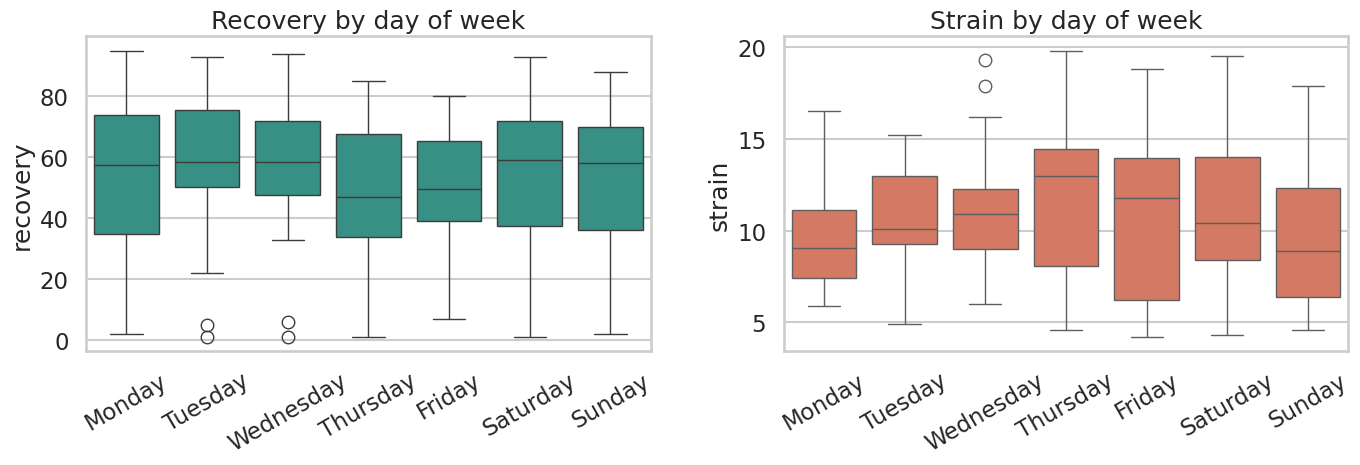

In [23]:
tmp = cycles_ts.copy()
tmp['dow_name'] = tmp['date'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=tmp, x='dow_name', y='recovery', order=order, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Recovery by day of week'); axes[0].set_xlabel('')
sns.boxplot(data=tmp, x='dow_name', y='strain',   order=order, ax=axes[1], color='#e76f51')
axes[1].set_title('Strain by day of week');   axes[1].set_xlabel('')
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_dow.png', dpi=130, bbox_inches='tight')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.show()


## 9 · Correlation structure

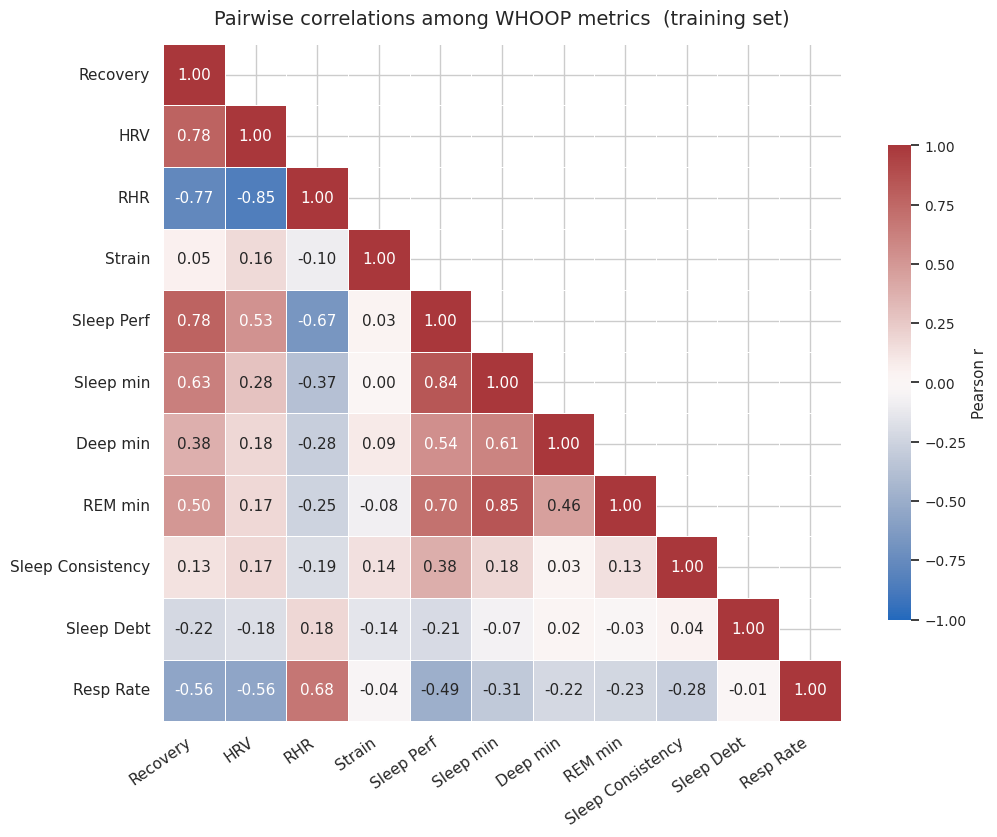

In [14]:
corr_cols = ['recovery','hrv','rhr','strain','sleep_perf','sleep_min',
             'deep_min','rem_min','sleep_consistency','sleep_debt_min','resp_rate']
nice_names = ['Recovery','HRV','RHR','Strain','Sleep Perf','Sleep min',
              'Deep min','REM min','Sleep Consistency','Sleep Debt','Resp Rate']
corr = cycles_train[corr_cols].corr()
corr.index = nice_names
corr.columns = nice_names

with sns.plotting_context('notebook', font_scale=0.9):
    fig, ax = plt.subplots(figsize=(11, 8.5))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle blank
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='vlag',
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.6,
        linecolor='white',
        annot_kws={'size': 11},
        cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
        ax=ax,
    )
    ax.set_title('Pairwise correlations among WHOOP metrics  (training set)',
                 fontsize=14, pad=14)
    ax.tick_params(axis='x', labelsize=11, rotation=35)
    ax.tick_params(axis='y', labelsize=11, rotation=0)
    plt.setp(ax.get_xticklabels(), ha='right')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/eda_corr.png', dpi=140, bbox_inches='tight')
    plt.show()


HRV is the single strongest correlate of Recovery (positive), and RHR is the strongest negative correlate. Sleep performance and sleep duration carry meaningful but secondary signal. Strain is essentially uncorrelated with same-day Recovery — its effect should show up *one day later*, which we'll test in the modeling notebook with lag features.

## 10 · Workout patterns (training period)

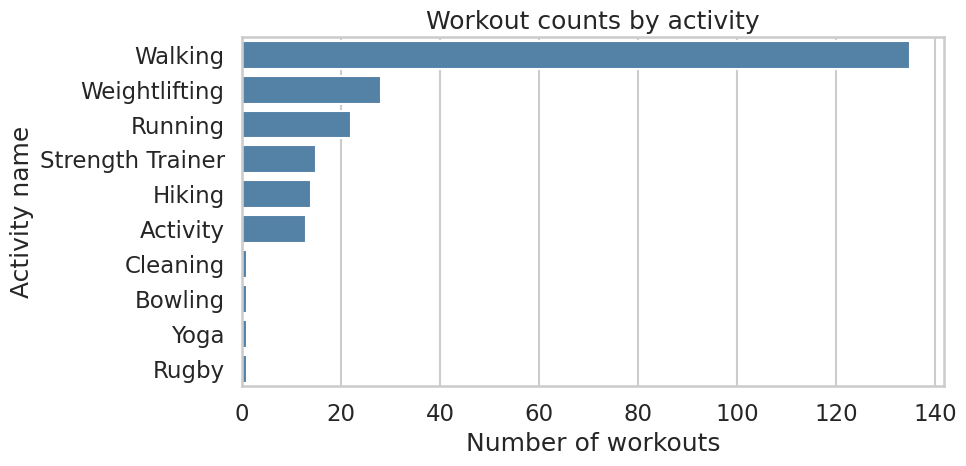

In [15]:
workouts_train = workouts[workouts['date'] < cutoff]
act = workouts_train['Activity name'].value_counts()
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=act.values, y=act.index, color='steelblue', ax=ax)
ax.set_title('Workout counts by activity')
ax.set_xlabel('Number of workouts')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_workouts.png', dpi=130, bbox_inches='tight')
plt.show()


Walking dominates the data, with running, weightlifting / strength training as the next most common explicit workouts.

## 11 · Journal habits over time (training period)

In [16]:
j = journal[journal['date'] < cutoff].copy()
j['yes'] = j['Answered yes'].astype(int)
q_summary = j.groupby('Question text')['yes'].agg(['sum','count','mean']).sort_values('mean', ascending=False)
q_summary.rename(columns={'mean':'fraction_yes'}, inplace=True)
q_summary.round(2)


,sum,count,fraction_yes
Question text,,,
Consumed protein?,9,9,1.00
Tracked your calories?,160,167,0.96
Consumed caffeine?,171,184,0.93
Consumed magnesium?,8,9,0.89
Ate food close to bedtime?,80,184,0.43
Have any alcoholic drinks?,62,184,0.34
Read (non-screened device) while in bed?,2,17,0.12
Dimmed your lights after sunset?,0,7,0.00
Saw direct sunlight upon waking up?,0,7,0.00


Caffeine is essentially a daily habit (>90% of logged days), late-night eating is also common. Alcohol is rare. These yes/no answers will become binary features in the model.

## 12 · Assemble the modeling frame and confirm shape

We build the full engineered frame here for caching, but split it again with `time_aware_split` so the modeling notebook receives the same train/test partition.

In [17]:
mdf = build_modeling_frame('/content')
mdf = mdf.drop_duplicates(subset='date', keep='last').reset_index(drop=True)
mdf = mdf.dropna(subset=['recovery_next','recovery_lag1']).reset_index(drop=True)

mdf_train, mdf_test, _ = time_aware_split(mdf, test_frac=0.20)

print('Full modeling frame:', mdf.shape)
print('Train:', mdf_train.shape, '   Test:', mdf_test.shape)
print('\nNext-day Recovery zone — training distribution:')
print(mdf_train['recovery_next_zone'].value_counts(dropna=False))

os.makedirs(DATA_DIR, exist_ok=True)
mdf.to_csv(f'{DATA_DIR}/whoop_modeling_frame.csv', index=False)
print('\nSaved → data/whoop_modeling_frame.csv')

Full modeling frame: (226, 72)
Train: (181, 72)    Test: (45, 72)

Next-day Recovery zone — training distribution:
recovery_next_zone
Yellow    88
Green     56
Red       37
Name: count, dtype: int64

Saved → data/whoop_modeling_frame.csv


## 13 · EDA takeaways feeding the modeling notebook

1. **Recovery is stationary** by ADF (no unit root), so an AR(p) model is appropriate without differencing.
2. **PACF cuts off after lag 1–2**, ACF decays gradually — the classic AR(1)/AR(2) signature. The modeling notebook will let PACF / AIC pick *p*.
3. **HRV ↑ and RHR ↓ are the dominant single-day correlates of Recovery** → expect them as the most important coefficients in a linear model.
4. **Sleep architecture (REM, deep, total) is collinear with total sleep**, so we'll keep them but expect Ridge shrinkage.
5. **Strain is delayed** in its effect → use lag-1 / lag-2 strain.
6. **Journal yes/no entries** add lifestyle context; only the regularly-asked ones (caffeine, alcohol, late food, tracked calories) have enough samples to be reliable predictors.
7. Recovery zone distribution is roughly **20% Red / 47% Yellow / 32% Green** — imbalanced but workable for classification.
